# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Maria Putu Evelyne Corena Puryatma | 5054251011 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    balanced_accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score, log_loss,
    jaccard_score, hamming_loss, top_k_accuracy_score, zero_one_loss,
)

pd.set_option('display.width', 160)
sns.set_style('whitegrid')

print('Library siap. seaborn versi:', sns.__version__)


Library siap. seaborn versi: 0.13.2


In [2]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv('WineQT.csv')

print(f'Jumlah baris  : {data.shape[0]}')
print(f'Jumlah kolom  : {data.shape[1]}')
print(f'Nama kolom    : {list(data.columns)}')
print(f'\nJumlah nilai yang hilang per kolom:')
print(data.isnull().sum().to_string())
print(f'\nJumlah baris duplikat: {data.duplicated().sum()}')

data.head()


Jumlah baris  : 1143
Jumlah kolom  : 13
Nama kolom    : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Jumlah nilai yang hilang per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0

Jumlah baris duplikat: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
data.info()

# Statistik deskriptif lengkap: selain describe(), ditambah range, skewness, dan kurtosis
# untuk melihat seberapa miring dan seberapa berekor tebal sebaran tiap fitur.
_num = [c for c in data.columns if c not in ('Id', 'quality')]
stat_desc = pd.DataFrame({
    'min': data[_num].min(),
    'max': data[_num].max(),
    'range': data[_num].max() - data[_num].min(),
    'mean': data[_num].mean(),
    'median': data[_num].median(),
    'std': data[_num].std(),
    'skew': data[_num].skew(),
    'kurtosis': data[_num].kurtosis(),
}).round(3)
print('Statistik deskriptif tiap fitur:')
print(stat_desc.to_string())

data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Statistik deskriptif tiap fitur:
                        min      max    ra

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


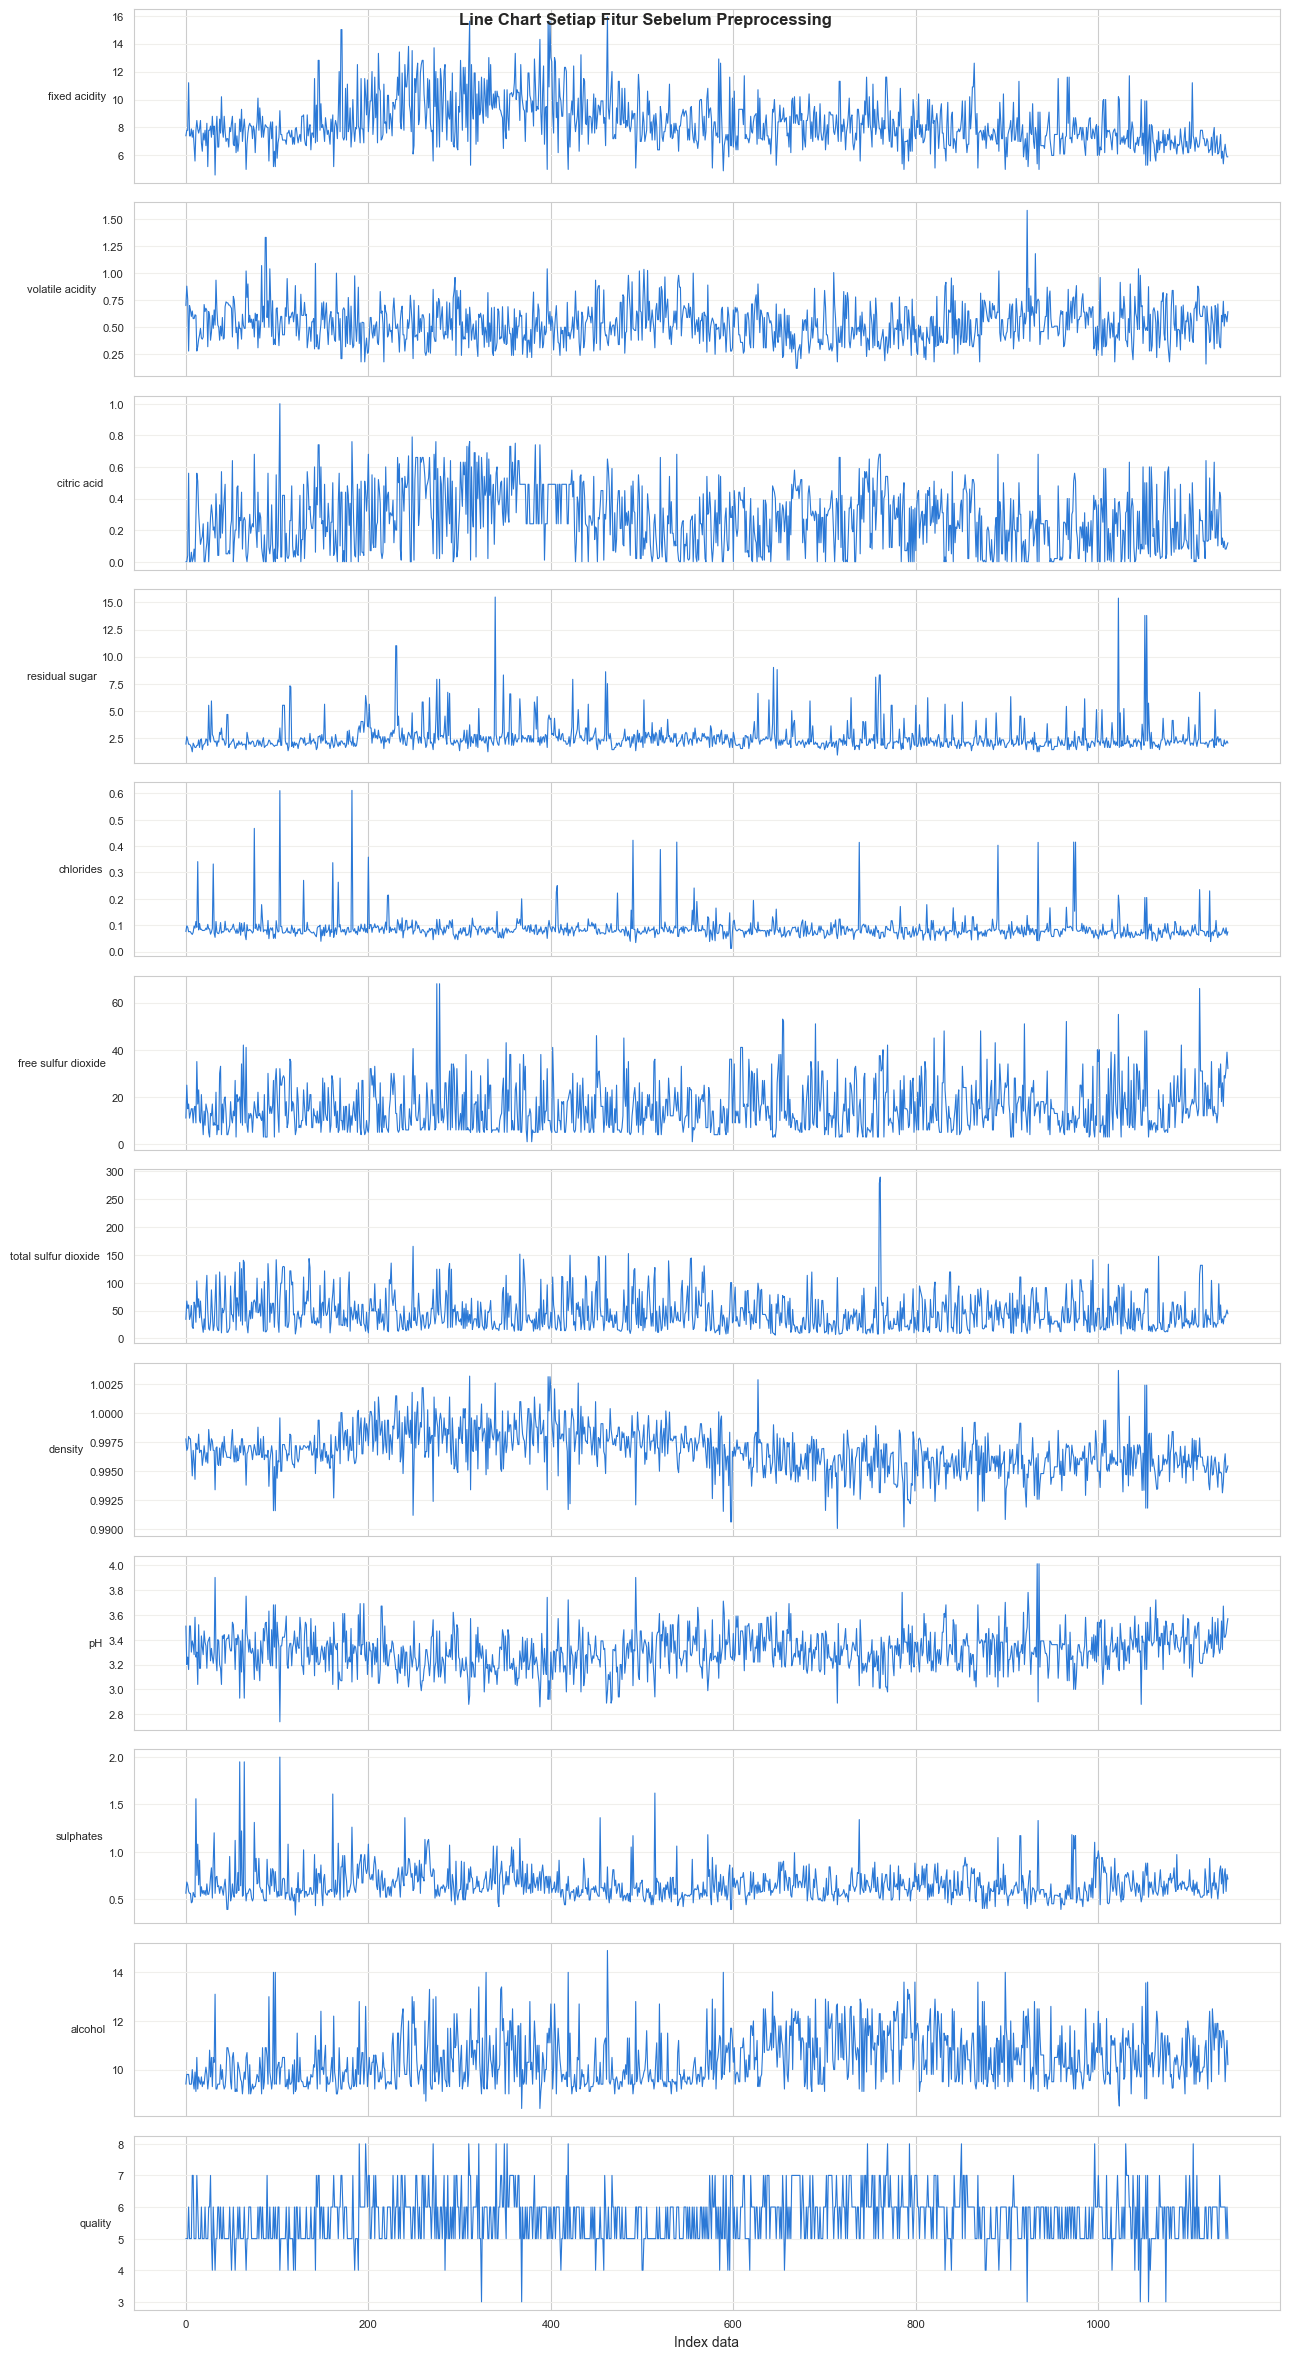

In [4]:
# Visualisasi setiap fitur sebelum preprocessing dalam bentuk line chart

FEATURES = [c for c in data.columns if c != 'Id']

fig, axes = plt.subplots(len(FEATURES), 1, figsize=(13, 2.0 * len(FEATURES)), sharex=True)
for ax, col in zip(axes, FEATURES):
    ax.plot(data.index, data[col], lw=.8, color='#2a78d6')
    ax.set_ylabel(col, fontsize=8, rotation=0, ha='right', va='center')
    ax.grid(axis='y', color='#f0efec', lw=.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8)
axes[-1].set_xlabel('Index data')
fig.suptitle('Line Chart Setiap Fitur Sebelum Preprocessing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Distribusi label quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16

Kelas mayoritas: 5 (42.3% dari seluruh data)


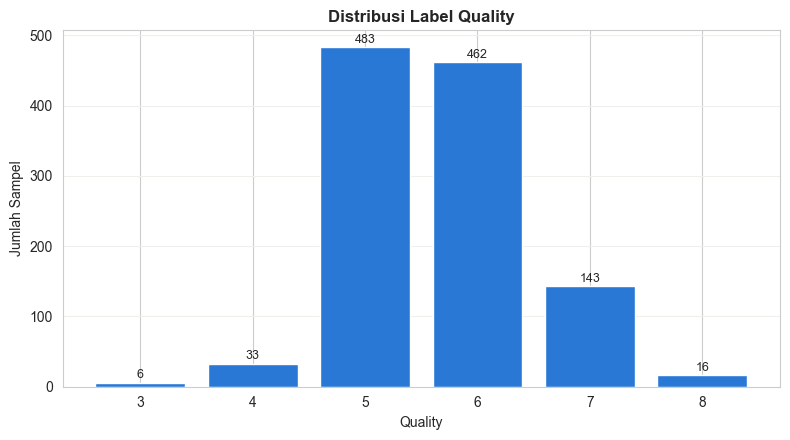

In [5]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

quality_counts = data['quality'].value_counts().sort_index()

print('Distribusi label quality:')
print(quality_counts.to_string())
print(f'\nKelas mayoritas: {quality_counts.idxmax()} '
      f'({quality_counts.max() / len(data) * 100:.1f}% dari seluruh data)')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(quality_counts.index.astype(str), quality_counts.values, color='#2a78d6')
ax.set_xlabel('Quality')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Label Quality', fontsize=12, fontweight='bold')
for i, v in enumerate(quality_counts.values):
    ax.text(i, v + 2, str(v), ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


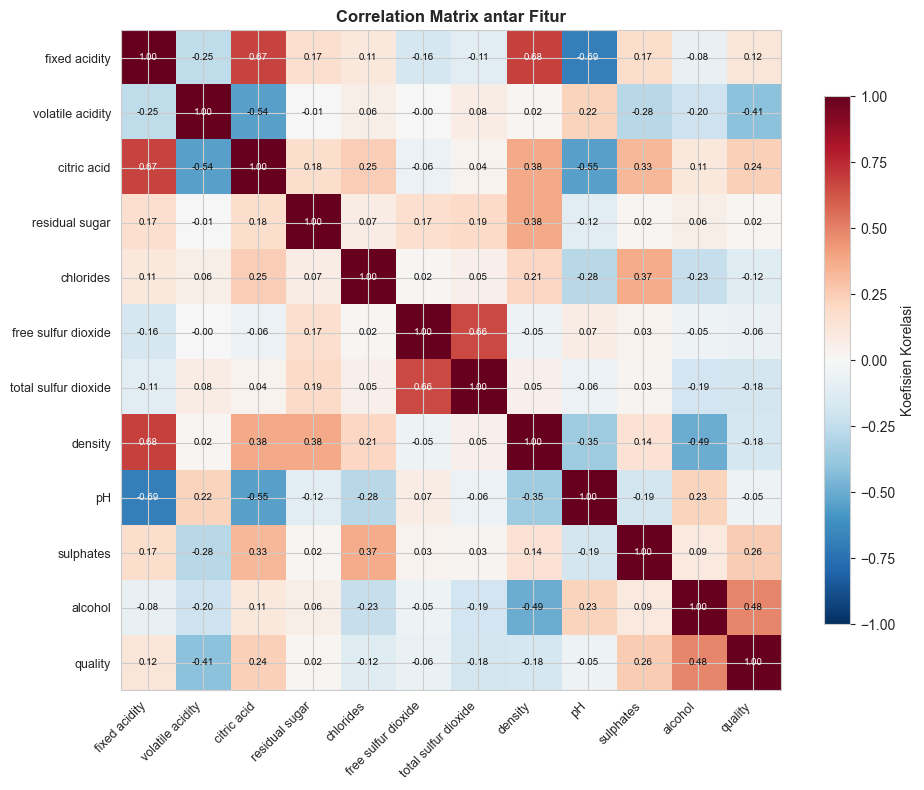

Ranking korelasi absolut tiap fitur terhadap quality:
alcohol                 0.485
volatile acidity        0.407
sulphates               0.258
citric acid             0.241
total sulfur dioxide    0.183
density                 0.175
chlorides               0.124
fixed acidity           0.122
free sulfur dioxide     0.063
pH                      0.052
residual sugar          0.022


In [6]:
#Korelasi Matrix

corr_cols = [c for c in data.columns if c != 'Id']
corr = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.6 else '#0b0b0b')
ax.set_title('Correlation Matrix antar Fitur', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, shrink=0.8, label='Koefisien Korelasi')
plt.tight_layout()
plt.show()

print('Ranking korelasi absolut tiap fitur terhadap quality:')
print(corr['quality'].drop('quality').abs().sort_values(ascending=False).round(3).to_string())


## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

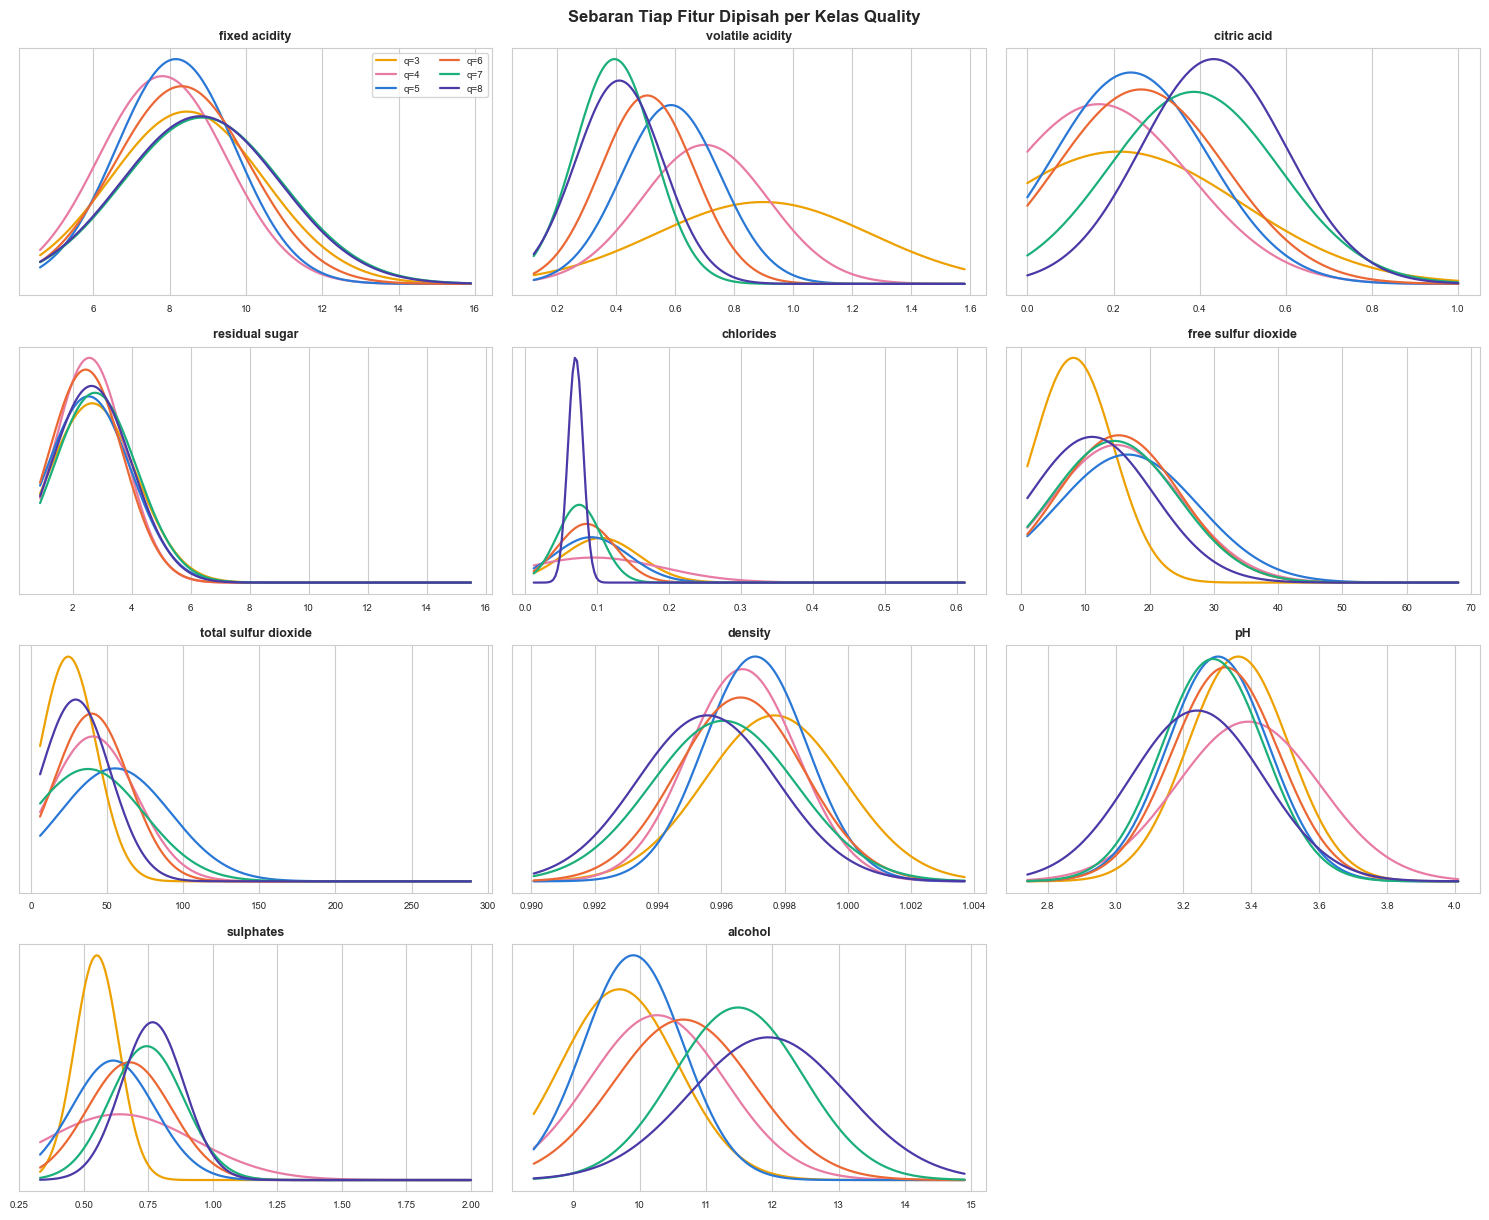

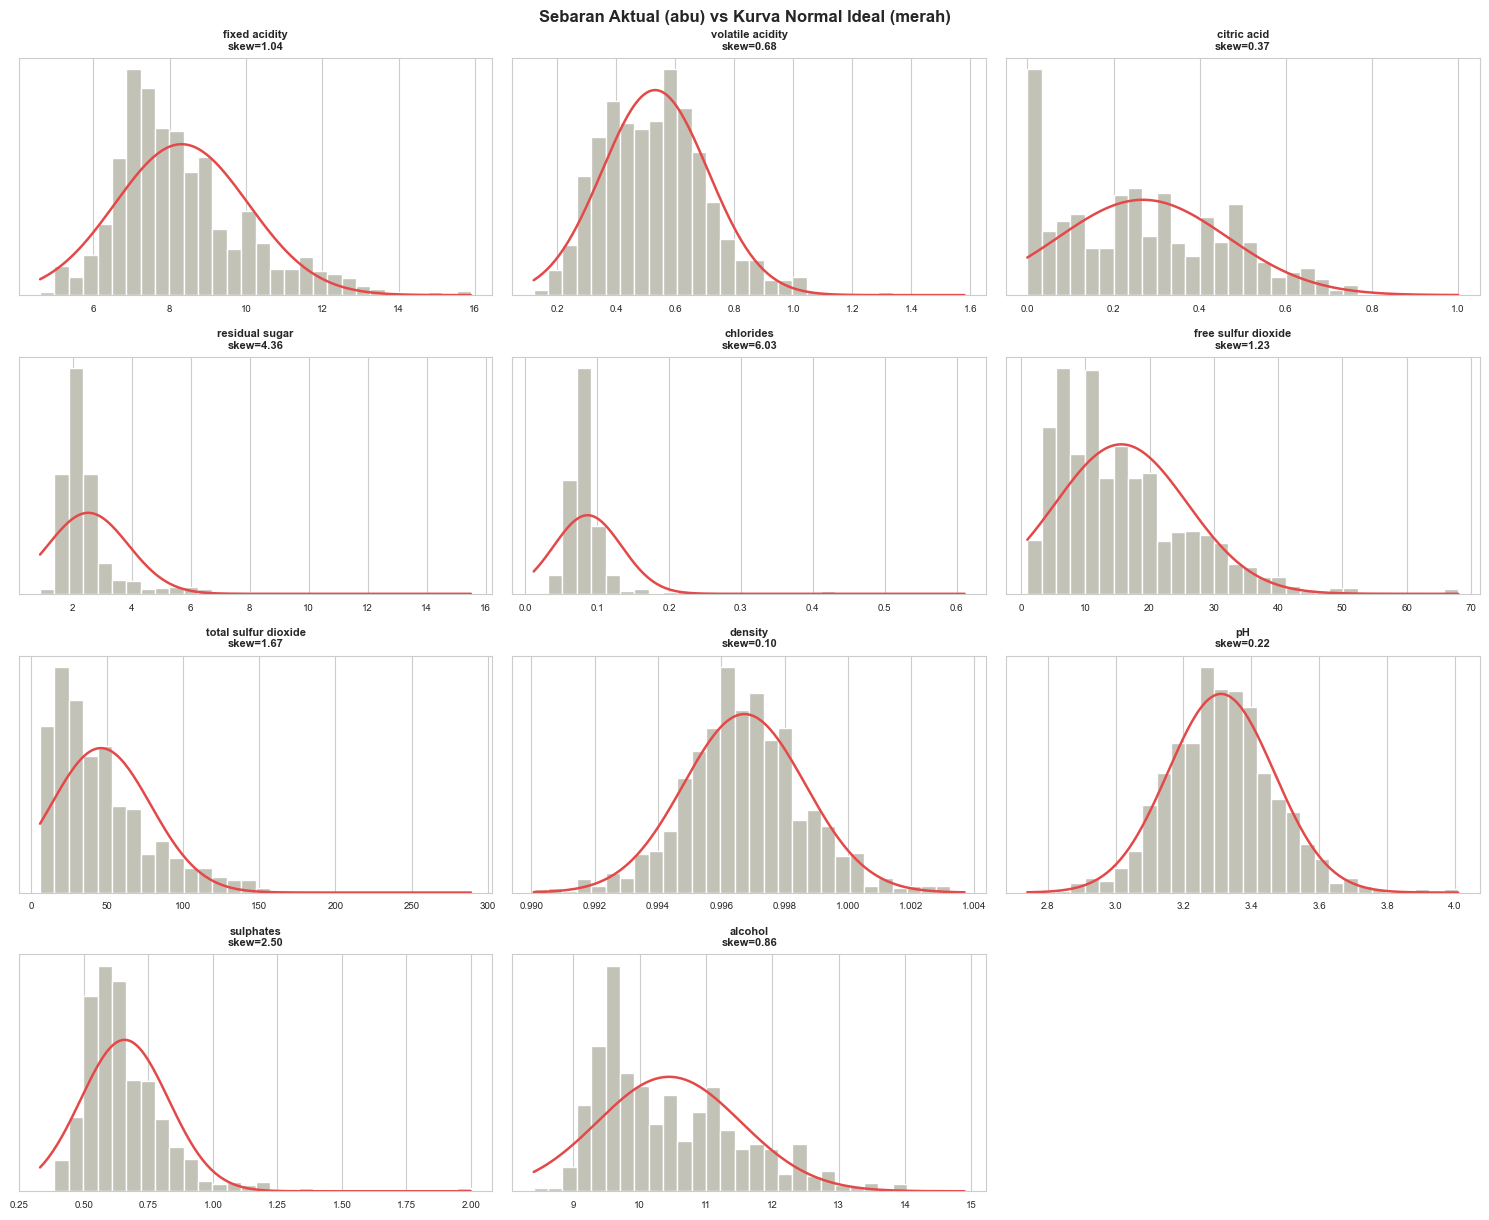

Fitur dengan skewness terbesar (paling jauh dari sebaran normal):
chlorides               6.03
residual sugar          4.36
sulphates               2.50
total sulfur dioxide    1.67
free sulfur dioxide     1.23


In [7]:
# EDA tambahan: sebaran tiap fitur per kelas quality dan pemeriksaan kenormalan sebaran

_num = [c for c in data.columns if c not in ('Id', 'quality')]
_labels = sorted(data['quality'].unique())
QCOLORS = {3: '#eda100', 4: '#e87ba4', 5: '#2a78d6', 6: '#eb6834', 7: '#1baf7a', 8: '#4a3aa7'}

# 1) Sebaran tiap fitur dipisah per kelas quality.
#    Fitur yang kurva antar kelasnya paling sedikit bertumpuk adalah fitur paling informatif.
nrow = int(np.ceil(len(_num) / 3))
fig, axes = plt.subplots(nrow, 3, figsize=(15, 3.1 * nrow))
for ax, col in zip(axes.ravel(), _num):
    for q in _labels:
        vals = data.loc[data['quality'] == q, col]
        if len(vals) < 2:
            continue
        xs = np.linspace(data[col].min(), data[col].max(), 200)
        # estimasi kepadatan sederhana memakai kurva normal dari mean & std tiap kelas
        ax.plot(xs, norm.pdf(xs, vals.mean(), vals.std() if vals.std() > 0 else 1e-6),
                lw=1.6, color=QCOLORS[q], label=f'q={q}')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_yticks([])
for ax in axes.ravel()[len(_num):]:
    ax.axis('off')
axes.ravel()[0].legend(fontsize=7, ncol=2)
fig.suptitle('Sebaran Tiap Fitur Dipisah per Kelas Quality', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 2) Perbandingan sebaran aktual terhadap kurva normal ideal.
fig, axes = plt.subplots(nrow, 3, figsize=(15, 3.1 * nrow))
for ax, col in zip(axes.ravel(), _num):
    ax.hist(data[col], bins=30, density=True, color='#c3c2b7')
    xs = np.linspace(data[col].min(), data[col].max(), 200)
    ax.plot(xs, norm.pdf(xs, data[col].mean(), data[col].std()), lw=1.8, color='#e34948')
    ax.set_title(f'{col}\nskew={data[col].skew():.2f}', fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_yticks([])
for ax in axes.ravel()[len(_num):]:
    ax.axis('off')
fig.suptitle('Sebaran Aktual (abu) vs Kurva Normal Ideal (merah)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Fitur dengan skewness terbesar (paling jauh dari sebaran normal):')
print(data[_num].skew().abs().sort_values(ascending=False).head(5).round(2).to_string())


# 2. Preprocessing




In [8]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

print('Missing value per kolom:')
print(data.isna().sum().to_string())
print('-> tidak ada nilai yang hilang, sehingga tidak perlu drop maupun impute.')

# Kolom Id hanya identifier, bukan fitur, sehingga diabaikan saat mencari duplikat.
feature_cols = [c for c in data.columns if c != 'Id']
n_dup = data.duplicated(subset=feature_cols).sum()
print(f'\nJumlah baris duplikat (Id diabaikan): {n_dup}')

before = len(data)
data = data.drop_duplicates(subset=feature_cols).reset_index(drop=True)
print(f'Jumlah baris: {before} -> {len(data)} (dihapus {before - len(data)})')


Missing value per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
-> tidak ada nilai yang hilang, sehingga tidak perlu drop maupun impute.

Jumlah baris duplikat (Id diabaikan): 125
Jumlah baris: 1143 -> 1018 (dihapus 125)


Ringkasan outlier per fitur (metode IQR):
                      Outliers Count  Outliers Percentage
residual sugar                    95                 9.33
chlorides                         71                 6.97
sulphates                         41                 4.03
fixed acidity                     37                 3.63
total sulfur dioxide              33                 3.24
density                           30                 2.95
pH                                24                 2.36
free sulfur dioxide               16                 1.57
volatile acidity                  10                 0.98
alcohol                            6                 0.59
citric acid                        1                 0.10



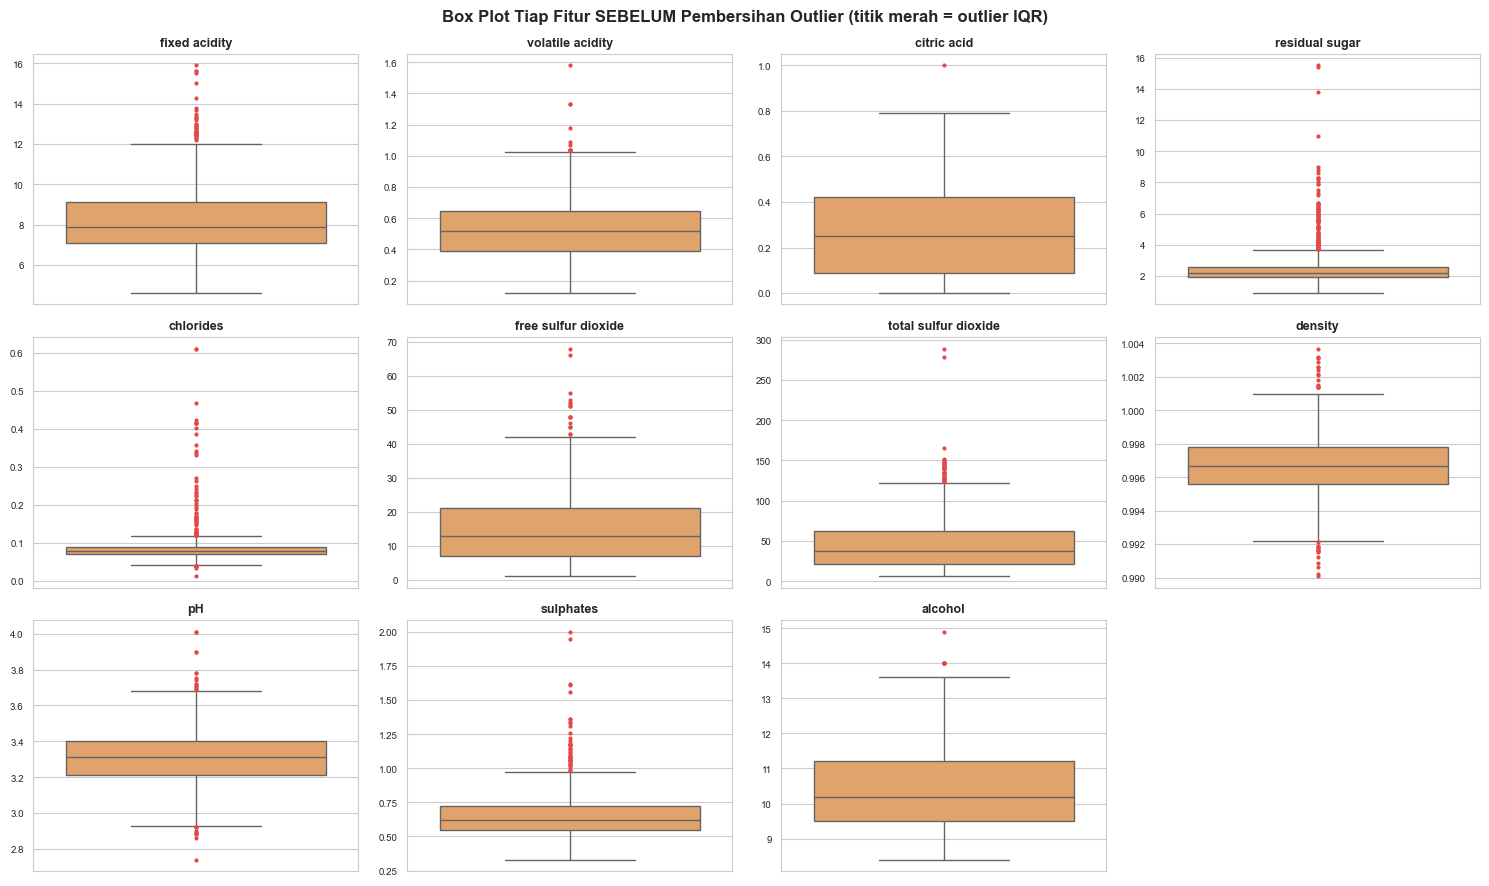


Tahap 1 (IQR): 1018 -> 756 baris (dibuang 262)
Tahap 2 (Isolation Forest): 756 -> 718 baris (dibuang 38)

Total data bersih: 718 baris

Distribusi quality setelah pembersihan:
quality
3      3
4     18
5    312
6    304
7     73
8      8


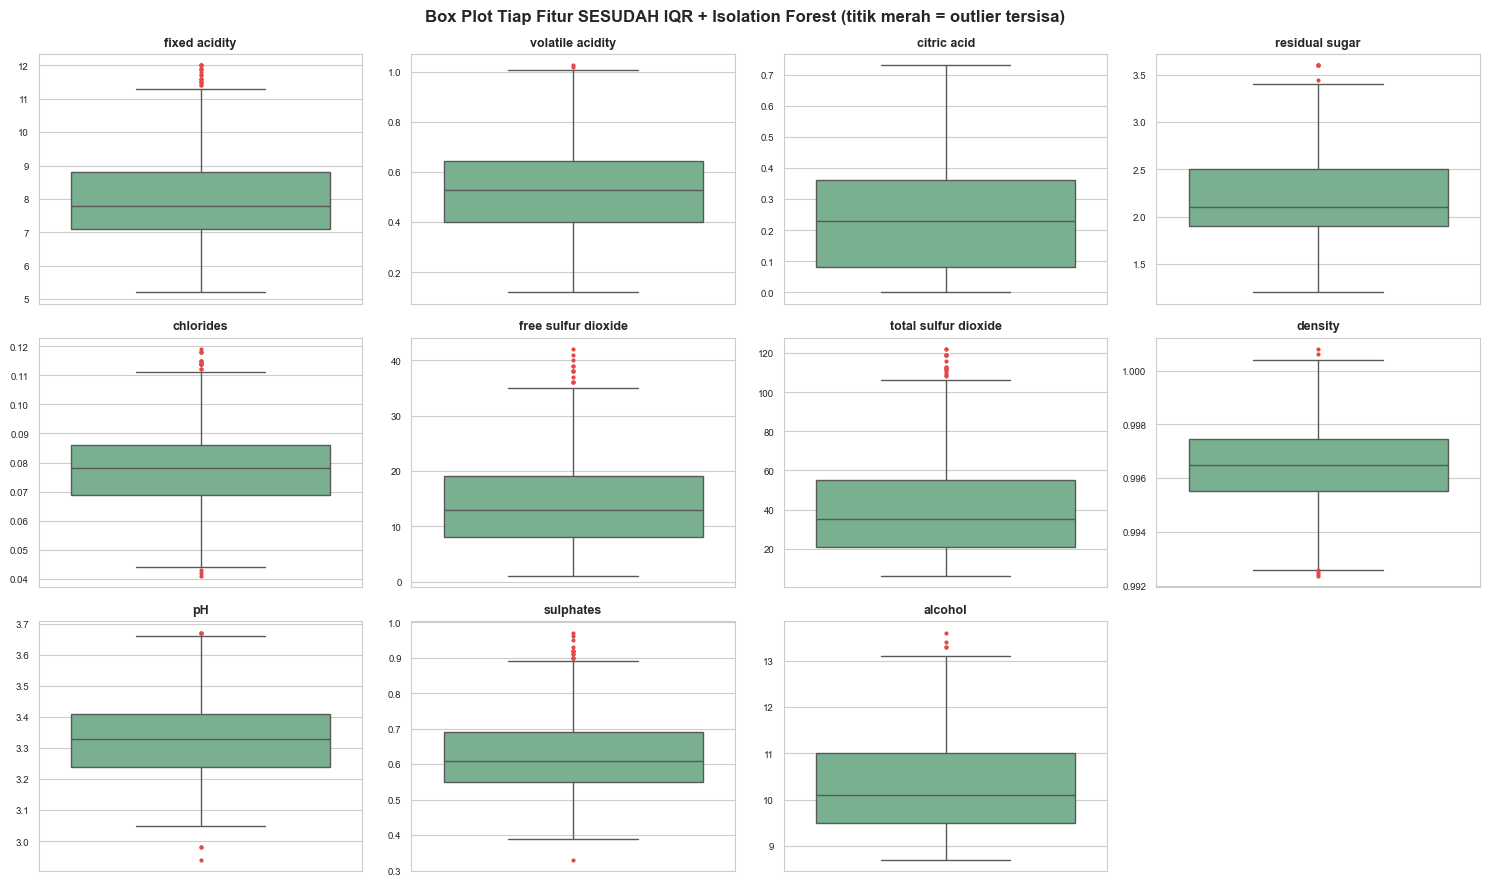

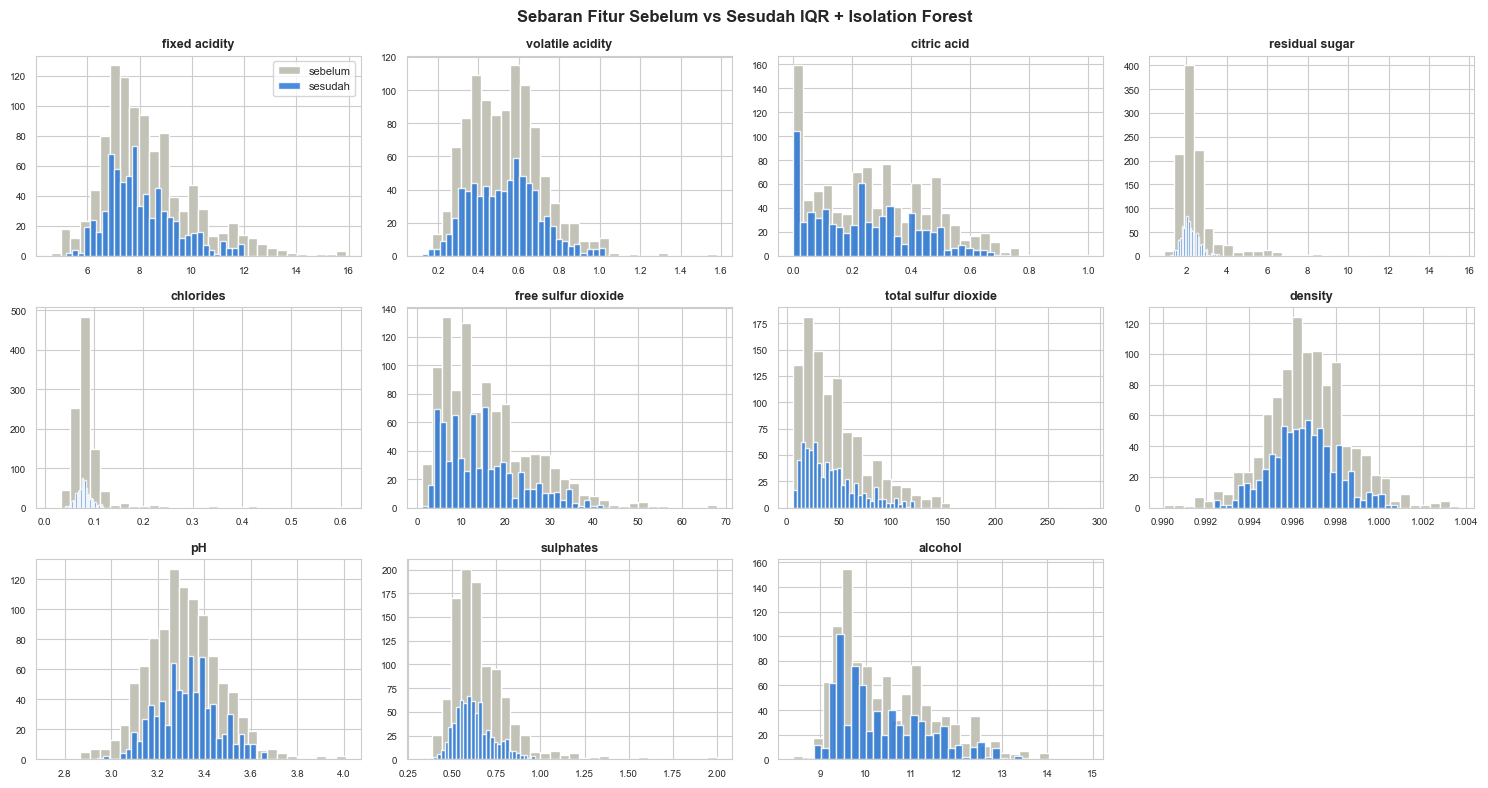

In [9]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)

# Dua tahap pembersihan:
#   1. IQR   -> membersihkan outlier pada tiap fitur secara individual (univariat)
#   2. Isolation Forest -> mendeteksi anomali multivariat, yaitu baris yang tiap
#      fiturnya terlihat wajar tetapi kombinasinya tidak masuk akal
numeric_cols = [c for c in data.columns if c not in ('Id', 'quality')]
data_before_outlier = data.copy()

# Ringkasan outlier per fitur: jumlah dan persentasenya terhadap total data
_Q1, _Q3 = data[numeric_cols].quantile(.25), data[numeric_cols].quantile(.75)
_IQR = _Q3 - _Q1
_is_out = (data[numeric_cols] < _Q1 - 1.5 * _IQR) | (data[numeric_cols] > _Q3 + 1.5 * _IQR)
outlier_table = pd.DataFrame({
    'Outliers Count': _is_out.sum(),
    'Outliers Percentage': (_is_out.sum() / len(data) * 100).round(2),
}).sort_values('Outliers Count', ascending=False)
print('Ringkasan outlier per fitur (metode IQR):')
print(outlier_table.to_string())
print()

# Box plot per fitur SEBELUM pembersihan -> titik di luar whisker adalah outlier
# menurut definisi IQR (di luar Q1-1.5*IQR atau Q3+1.5*IQR). Dipakai untuk MELIHAT
# outlier secara visual, sedangkan pembersihan sesungguhnya tetap memakai IQR + Isolation Forest di bawah.
nrow_bp = int(np.ceil(len(numeric_cols) / 4))
fig, axes = plt.subplots(nrow_bp, 4, figsize=(15, 3.0 * nrow_bp))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(y=data[col], ax=ax, color='#f4a259', fliersize=3,
                flierprops=dict(markerfacecolor='#e34948', markeredgecolor='none'))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('')
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(numeric_cols):]:
    ax.axis('off')
fig.suptitle('Box Plot Tiap Fitur SEBELUM Pembersihan Outlier (titik merah = outlier IQR)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Tahap 1: IQR per fitur ---
# Baris yang punya outlier di fitur mana pun akan dibuang.
iqr_mask = ~_is_out.any(axis=1)

before = len(data)
data = data[iqr_mask].reset_index(drop=True)
print(f'\nTahap 1 (IQR): {before} -> {len(data)} baris (dibuang {before - len(data)})')

# --- Tahap 2: Isolation Forest ---
CONTAMINATION = 0.05   # asumsi maksimal 5% data merupakan anomali multivariat
iso_input = StandardScaler().fit_transform(data[numeric_cols])
iso_flag = IsolationForest(contamination=CONTAMINATION, random_state=42).fit_predict(iso_input)

before = len(data)
data = data[iso_flag == 1].reset_index(drop=True)
print(f'Tahap 2 (Isolation Forest): {before} -> {len(data)} baris (dibuang {before - len(data)})')

print(f'\nTotal data bersih: {len(data)} baris')
print('\nDistribusi quality setelah pembersihan:')
print(data['quality'].value_counts().sort_index().to_string())

# Box plot per fitur SESUDAH pembersihan (IQR + Isolation Forest) -> dibandingkan dengan
# box plot sebelum pembersihan di atas, whisker/outlier yang tersisa seharusnya jauh berkurang.
fig, axes = plt.subplots(nrow_bp, 4, figsize=(15, 3.0 * nrow_bp))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(y=data[col], ax=ax, color='#6fb98f', fliersize=3,
                flierprops=dict(markerfacecolor='#e34948', markeredgecolor='none'))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('')
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(numeric_cols):]:
    ax.axis('off')
fig.suptitle('Box Plot Tiap Fitur SESUDAH IQR + Isolation Forest (titik merah = outlier tersisa)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Perbandingan sebaran sebelum vs sesudah pembersihan (tanpa boxplot)
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(data_before_outlier[col], bins=30, color='#c3c2b7', label='sebelum')
    ax.hist(data[col], bins=30, color='#2a78d6', alpha=.85, label='sesudah')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(numeric_cols):]:
    ax.axis('off')
axes.ravel()[0].legend(fontsize=8)
fig.suptitle('Sebaran Fitur Sebelum vs Sesudah IQR + Isolation Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Ranking korelasi absolut terhadap quality:
alcohol                 0.516
sulphates               0.447
volatile acidity        0.388
citric acid             0.261
total sulfur dioxide    0.223
density                 0.221
chlorides               0.200
fixed acidity           0.134
pH                      0.080
residual sugar          0.042
free sulfur dioxide     0.024

Ambang korelasi   : 0.2
Fitur dipakai (7) : ['alcohol', 'sulphates', 'volatile acidity', 'citric acid', 'total sulfur dioxide', 'density', 'chlorides']
Fitur dibuang (4) : ['fixed acidity', 'pH', 'residual sugar', 'free sulfur dioxide']


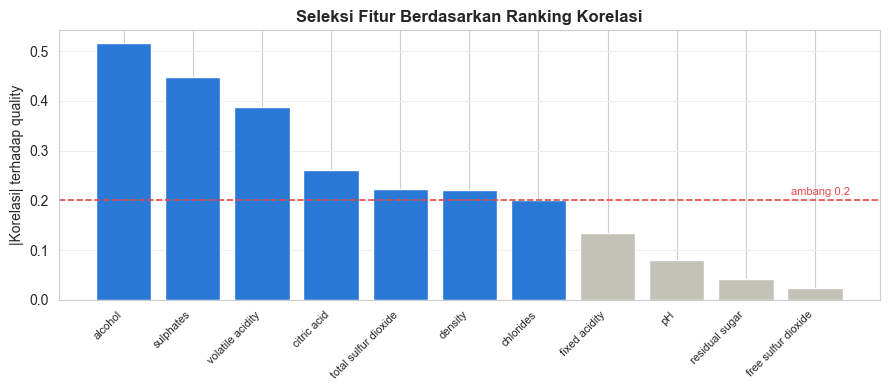

In [10]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

# --- Seleksi fitur berdasarkan ranking korelasi terhadap quality ---
CORR_THRESHOLD = 0.20

corr_rank = data[numeric_cols + ['quality']].corr()['quality'].drop('quality').abs().sort_values(ascending=False)
selected_features = list(corr_rank[corr_rank >= CORR_THRESHOLD].index)
dropped_features = list(corr_rank[corr_rank < CORR_THRESHOLD].index)

print('Ranking korelasi absolut terhadap quality:')
print(corr_rank.round(3).to_string())
print(f'\nAmbang korelasi   : {CORR_THRESHOLD}')
print(f'Fitur dipakai ({len(selected_features)}) : {selected_features}')
print(f'Fitur dibuang ({len(dropped_features)}) : {dropped_features}')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2a78d6' if c in selected_features else '#c3c2b7' for c in corr_rank.index]
ax.bar(range(len(corr_rank)), corr_rank.values, color=colors)
ax.axhline(CORR_THRESHOLD, color='#e34948', ls='--', lw=1.2)
ax.text(len(corr_rank) - .5, CORR_THRESHOLD + .01, f'ambang {CORR_THRESHOLD}',
        ha='right', fontsize=8, color='#e34948')
ax.set_xticks(range(len(corr_rank)))
ax.set_xticklabels(corr_rank.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('|Korelasi| terhadap quality')
ax.set_title('Seleksi Fitur Berdasarkan Ranking Korelasi', fontsize=12, fontweight='bold')
ax.grid(axis='y', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# --- Scaler ---
# KNN berbasis jarak, sehingga fitur berskala besar akan mendominasi perhitungan jarak.
# Dua pendekatan disiapkan untuk dibandingkan pada bagian 3:
#   Normalized   -> MinMaxScaler, memampatkan tiap fitur ke rentang 0..1
#   Standardized -> StandardScaler, mengubah tiap fitur menjadi mean 0 dan std 1
# Keduanya baru di-fit SETELAH train-test split agar tidak terjadi data leakage.
scalers = {
    'Normalized (MinMaxScaler)': MinMaxScaler(),
    'Standardized (StandardScaler)': StandardScaler(),
}
scaler = scalers['Standardized (StandardScaler)']


# 3. Eksperimen Model KNN


Train: 574 baris | Test: 144 baris

KNN (k=5) TANPA scaling  : 0.4861
KNN (k=5) DENGAN scaling : 0.5972
Selisih                  : +0.1111
-> scaling wajib untuk KNN karena fitur seperti total sulfur dioxide (skala ratusan)
   akan mendominasi perhitungan jarak dibanding fitur seperti citric acid (skala < 1).


/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/


Perbandingan teknik scaling:
                        Scale  Train Score  CV Score  Test Score                                                       Best Params
    Normalized (MinMaxScaler)          1.0    0.5997      0.6458 {'metric': 'manhattan', 'n_neighbors': 61, 'weights': 'distance'}
Standardized (StandardScaler)          1.0    0.5990      0.6458 {'metric': 'manhattan', 'n_neighbors': 65, 'weights': 'distance'}

Scaler terpilih: Normalized (MinMaxScaler)


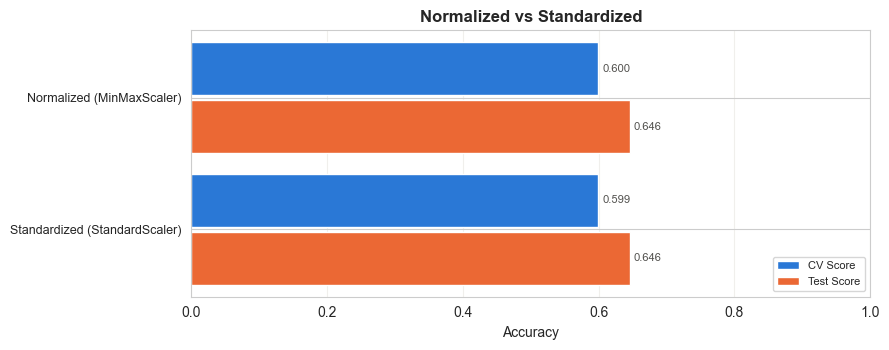

/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Parameter terbaik : {'metric': 'manhattan', 'n_neighbors': 61, 'weights': 'distance'}
CV accuracy       : 0.5997

Total kombinasi diuji: 240

10 kombinasi terbaik berdasarkan cross-validation:
 k    metric  weights  train_accuracy  cv_accuracy  test_accuracy
61 manhattan distance             1.0       0.5997         0.6458
59 manhattan distance             1.0       0.5990         0.6319
55 manhattan distance             1.0       0.5973         0.6181
67 manhattan distance             1.0       0.5973         0.6528
63 euclidean distance             1.0       0.5969         0.6181
71 manhattan distance             1.0       0.5969         0.6250
67 euclidean distance             1.0       0.5966         0.6319
63 manhattan distance             1.0       0.5966         0.6458
65 euclidean distance             1.0       0.5966         0.6250
65 manhattan distance             1.0       0.5962         0.6528


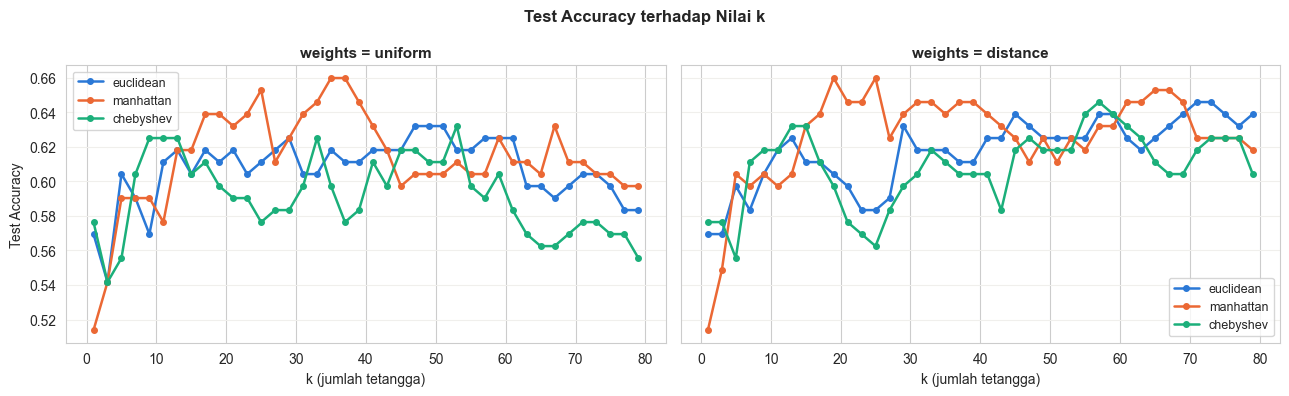

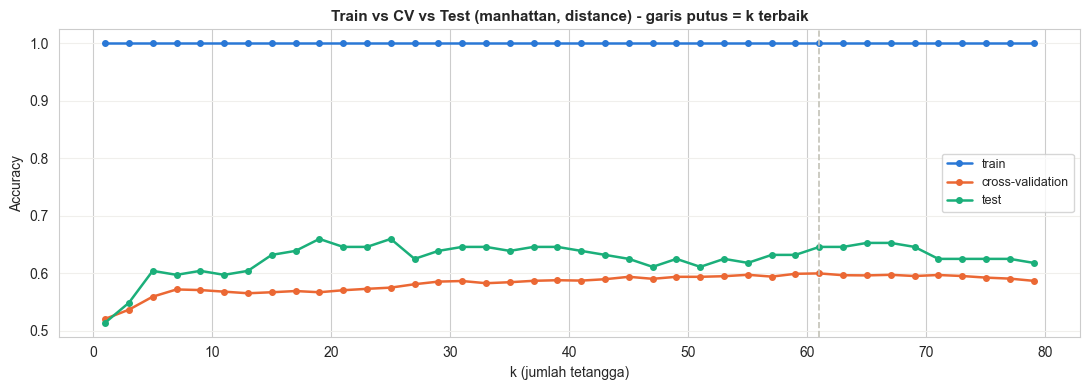

In [11]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

X = data[selected_features]
y = data['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris')

# --- Bukti pentingnya scaling untuk KNN (metode "Scaling Matters" dari knn-tutorial) ---
# KNN berbasis jarak, jadi kita buktikan dulu efeknya sebelum masuk ke eksperimen utama:
# bandingkan KNN k=5 memakai fitur MENTAH (tanpa scaling) vs fitur yang SUDAH discaling.
knn_noscale = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
acc_noscale = accuracy_score(y_test, knn_noscale.predict(X_test))

_tmp_scaler = StandardScaler().fit(X_train)
knn_scaled_demo = KNeighborsClassifier(n_neighbors=5).fit(_tmp_scaler.transform(X_train), y_train)
acc_scaled_demo = accuracy_score(y_test, knn_scaled_demo.predict(_tmp_scaler.transform(X_test)))

print(f'\nKNN (k=5) TANPA scaling  : {acc_noscale:.4f}')
print(f'KNN (k=5) DENGAN scaling : {acc_scaled_demo:.4f}')
print(f'Selisih                  : {(acc_scaled_demo - acc_noscale):+.4f}')
print('-> scaling wajib untuk KNN karena fitur seperti total sulfur dioxide (skala ratusan)')
print('   akan mendominasi perhitungan jarak dibanding fitur seperti citric acid (skala < 1).')

# Rentang k dan pilihan distance metric diperluas mengikuti metode grid search menyeluruh
# pada knn-tutorial (K-sweep lebar 1-79 + beberapa distance metric, termasuk chebyshev)
# supaya kombinasi hyperparameter yang benar-benar lebih akurat tidak terlewat.
param_grid = {
    'n_neighbors': list(range(1, 80, 2)),
    'metric': ['euclidean', 'manhattan', 'chebyshev'],
    'weights': ['uniform', 'distance'],
}
# 5-fold biasa sangat sensitif terhadap noise pada dataset sekecil ini (test hanya ~144 baris),
# sehingga skor CV antar scaler bisa terbalik hanya karena pembagian fold yang berbeda.
# RepeatedStratifiedKFold (5 fold x 5 ulangan = 25 estimasi) dipakai agar pemilihan
# scaler & hyperparameter lebih stabil dan tidak mengandalkan satu pembagian fold saja.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# --- Bandingkan Normalized (MinMaxScaler) vs Standardized (StandardScaler) ---
# Scaling dilakukan SETELAH split: fit hanya pada train, lalu transform keduanya.
scale_scores = []
for scale_name, scale_obj in scalers.items():
    a = scale_obj.fit_transform(X_train)
    b = scale_obj.transform(X_test)
    gs = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    gs.fit(a, y_train)
    est = gs.best_estimator_
    scale_scores.append({
        'Scale': scale_name,
        'Train Score': accuracy_score(y_train, est.predict(a)),
        'CV Score': gs.best_score_,
        'Test Score': accuracy_score(y_test, est.predict(b)),
        'Best Params': str(gs.best_params_),
    })

model_scores = pd.DataFrame(scale_scores)
print('\nPerbandingan teknik scaling:')
print(model_scores.round(4).to_string(index=False))

# Scaler dengan CV Score tertinggi dipakai untuk seluruh tahap berikutnya
best_scale_name = model_scores.loc[model_scores['CV Score'].idxmax(), 'Scale']
scaler = scalers[best_scale_name]
print(f'\nScaler terpilih: {best_scale_name}')

fig, ax = plt.subplots(figsize=(9, 3.6))
ypos = np.arange(len(model_scores))
ax.barh(ypos - .22, model_scores['CV Score'], height=.4, color='#2a78d6', label='CV Score')
ax.barh(ypos + .22, model_scores['Test Score'], height=.4, color='#eb6834', label='Test Score')
ax.set_yticks(ypos); ax.set_yticklabels(model_scores['Scale'], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('Accuracy'); ax.set_xlim(0, 1)
for j, r in enumerate(model_scores.itertuples()):
    ax.text(r._3 + .006, j - .22, f'{r._3:.3f}', va='center', fontsize=8, color='#52514e')
    ax.text(r._4 + .006, j + .22, f'{r._4:.3f}', va='center', fontsize=8, color='#52514e')
ax.set_title('Normalized vs Standardized', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='x', color='#f0efec', lw=.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# --- GridSearchCV final memakai scaler terpilih ---
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_k = grid.best_params_['n_neighbors']
best_metric = grid.best_params_['metric']
best_weights = grid.best_params_['weights']
print(f'\nParameter terbaik : {grid.best_params_}')
print(f'CV accuracy       : {grid.best_score_:.4f}')

# --- Catat performa train & test untuk tiap kombinasi ---
experiment_results = []
knn_models = {}
for metric in param_grid['metric']:
    for weights in param_grid['weights']:
        for k in param_grid['n_neighbors']:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)
            knn.fit(X_train_scaled, y_train)
            experiment_results.append({
                'k': k, 'metric': metric, 'weights': weights,
                'train_accuracy': accuracy_score(y_train, knn.predict(X_train_scaled)),
                'test_accuracy': accuracy_score(y_test, knn.predict(X_test_scaled)),
            })
            knn_models[(k, metric, weights)] = knn

results_df = pd.DataFrame(experiment_results)
cv_map = {(p['n_neighbors'], p['metric'], p['weights']): s
          for p, s in zip(grid.cv_results_['params'], grid.cv_results_['mean_test_score'])}
results_df['cv_accuracy'] = [cv_map[(r.k, r.metric, r.weights)] for r in results_df.itertuples()]
results_df = results_df[['k', 'metric', 'weights', 'train_accuracy', 'cv_accuracy', 'test_accuracy']]
results_df = results_df.sort_values('cv_accuracy', ascending=False).reset_index(drop=True)

print(f'\nTotal kombinasi diuji: {len(results_df)}')
print('\n10 kombinasi terbaik berdasarkan cross-validation:')
print(results_df.head(10).round(4).to_string(index=False))

# --- Visualisasi hasil eksperimen ---
metric_colors = ['#2a78d6', '#eb6834', '#1baf7a']
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, weights in zip(axes, param_grid['weights']):
    for metric, color in zip(param_grid['metric'], metric_colors):
        sub = results_df[(results_df.metric == metric) & (results_df.weights == weights)].sort_values('k')
        ax.plot(sub['k'], sub['test_accuracy'], marker='o', markersize=4, lw=1.8, label=metric, color=color)
    ax.set_title(f'weights = {weights}', fontsize=11, fontweight='bold')
    ax.set_xlabel('k (jumlah tetangga)')
    ax.grid(axis='y', color='#f0efec', lw=.8)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9)
axes[0].set_ylabel('Test Accuracy')
fig.suptitle('Test Accuracy terhadap Nilai k', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
sub = results_df[(results_df.metric == best_metric) & (results_df.weights == best_weights)].sort_values('k')
ax.plot(sub['k'], sub['train_accuracy'], marker='o', markersize=4, lw=1.8, label='train', color='#2a78d6')
ax.plot(sub['k'], sub['cv_accuracy'], marker='o', markersize=4, lw=1.8, label='cross-validation', color='#eb6834')
ax.plot(sub['k'], sub['test_accuracy'], marker='o', markersize=4, lw=1.8, label='test', color='#1baf7a')
ax.axvline(best_k, color='#c3c2b7', ls='--', lw=1.2)
ax.set_xlabel('k (jumlah tetangga)')
ax.set_ylabel('Accuracy')
ax.set_title(f'Train vs CV vs Test ({best_metric}, {best_weights}) - garis putus = k terbaik',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


# 4. Evaluasi Model


Model terbaik : k=61, metric=manhattan, weights=distance
Train accuracy: 1.0000
CV accuracy   : 0.5997
Test accuracy : 0.6458

Classification Report (Precision, Recall, F1-Score per kelas):
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         4
           5       0.66      0.82      0.73        62
           6       0.62      0.64      0.63        61
           7       0.75      0.20      0.32        15
           8       0.00      0.00      0.00         2

    accuracy                           0.65       144
   macro avg       0.41      0.33      0.34       144
weighted avg       0.63      0.65      0.62       144



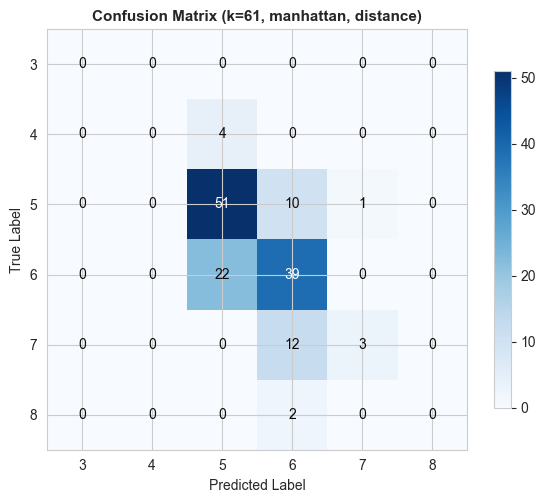


=== Ringkasan Semua Metrik Evaluasi (Test Set, model KNN terbaik) ===
                    Metric  Value
                  Accuracy 0.6458
         Balanced Accuracy 0.3324
         Precision (macro) 0.4063
      Precision (weighted) 0.6255
            Recall (macro) 0.3324
         Recall (weighted) 0.6458
          F1-Score (macro) 0.3357
       F1-Score (weighted) 0.6153
          F1-Score (micro) 0.6458
             Cohen's Kappa 0.3910
Matthews Corr. Coef. (MCC) 0.3987
     Jaccard Score (macro) 0.2452
              Hamming Loss 0.3542
             Zero-One Loss 0.3542
                  Log Loss 1.1488
      ROC-AUC (OvR, macro) 0.8035
            Top-2 Accuracy 0.9028


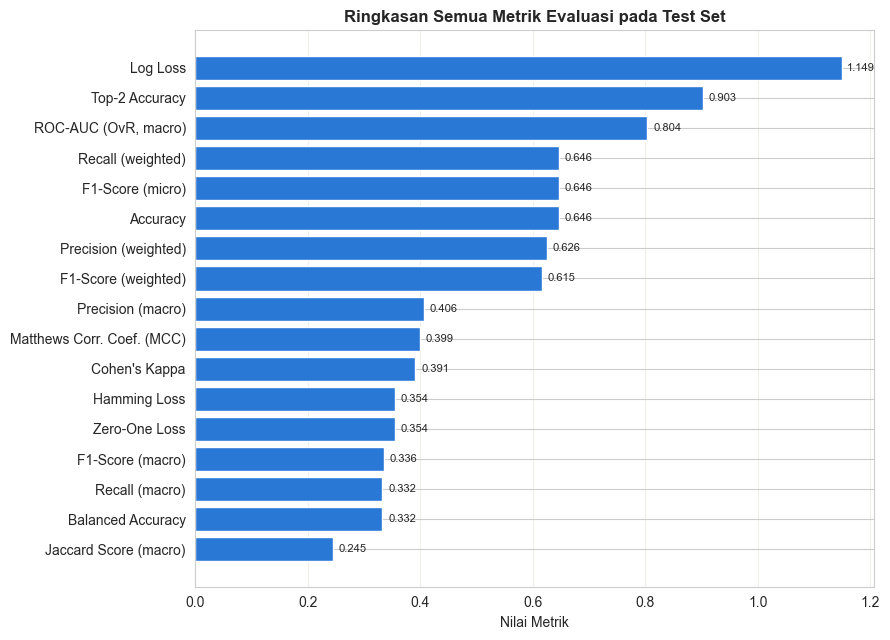

/opt/miniconda3/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


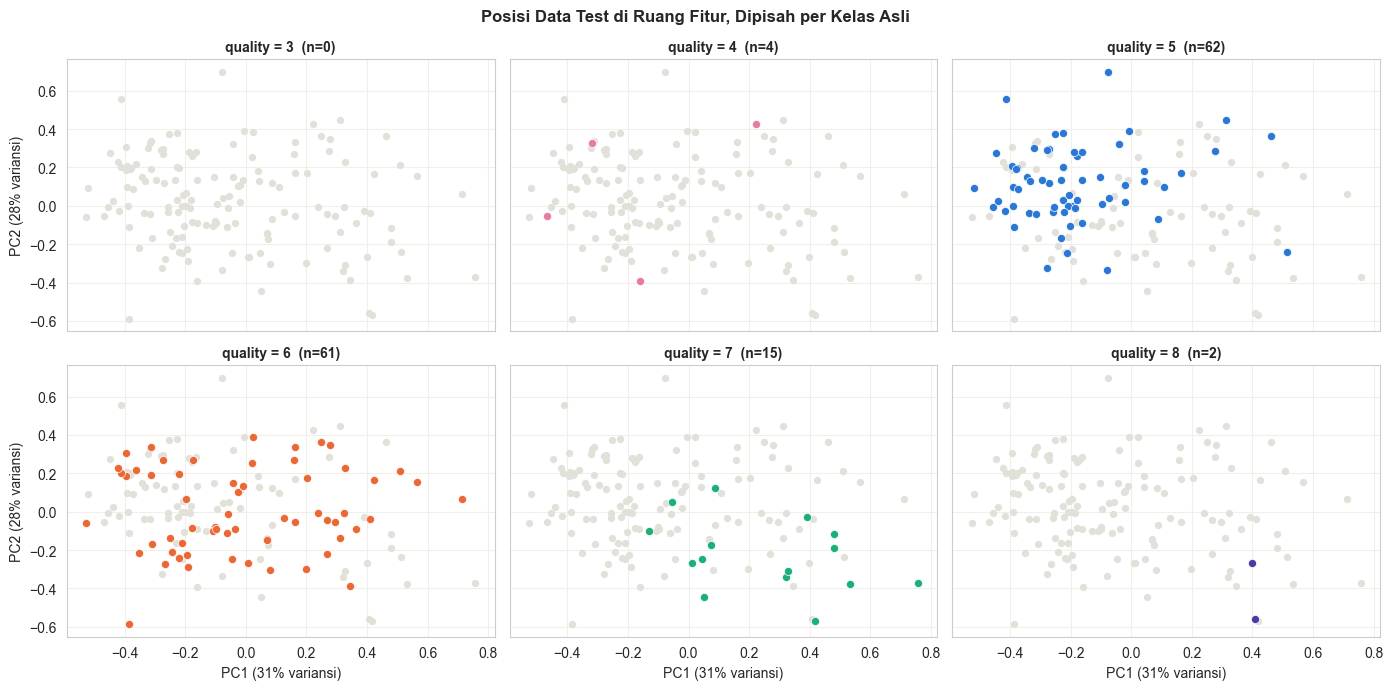

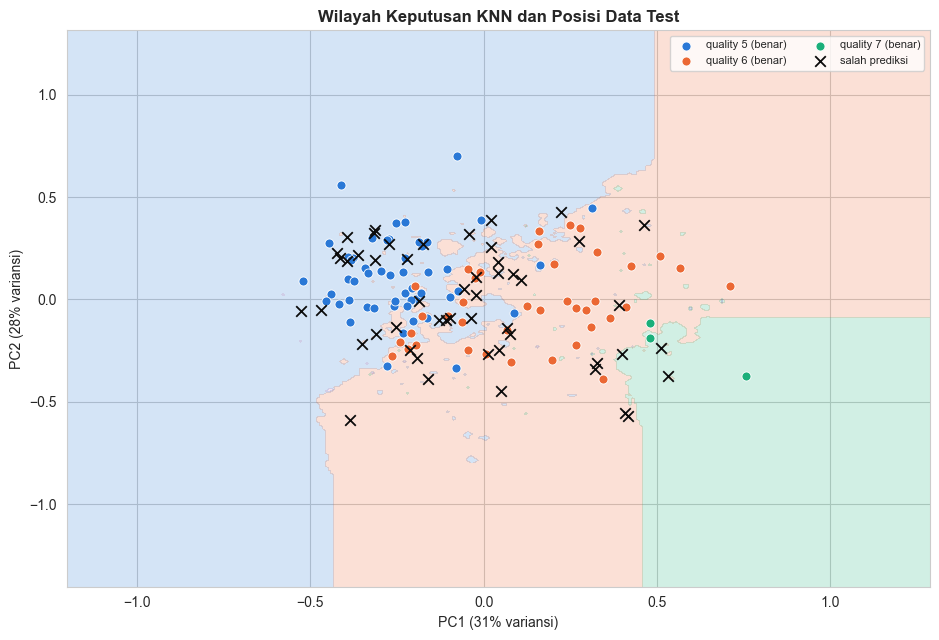

Kelas yang pernah diprediksi model : [5, 6, 7]
Kelas yang TIDAK pernah diprediksi : [3, 4, 8] -> sampelnya terlalu sedikit untuk memenangkan voting tetangga.


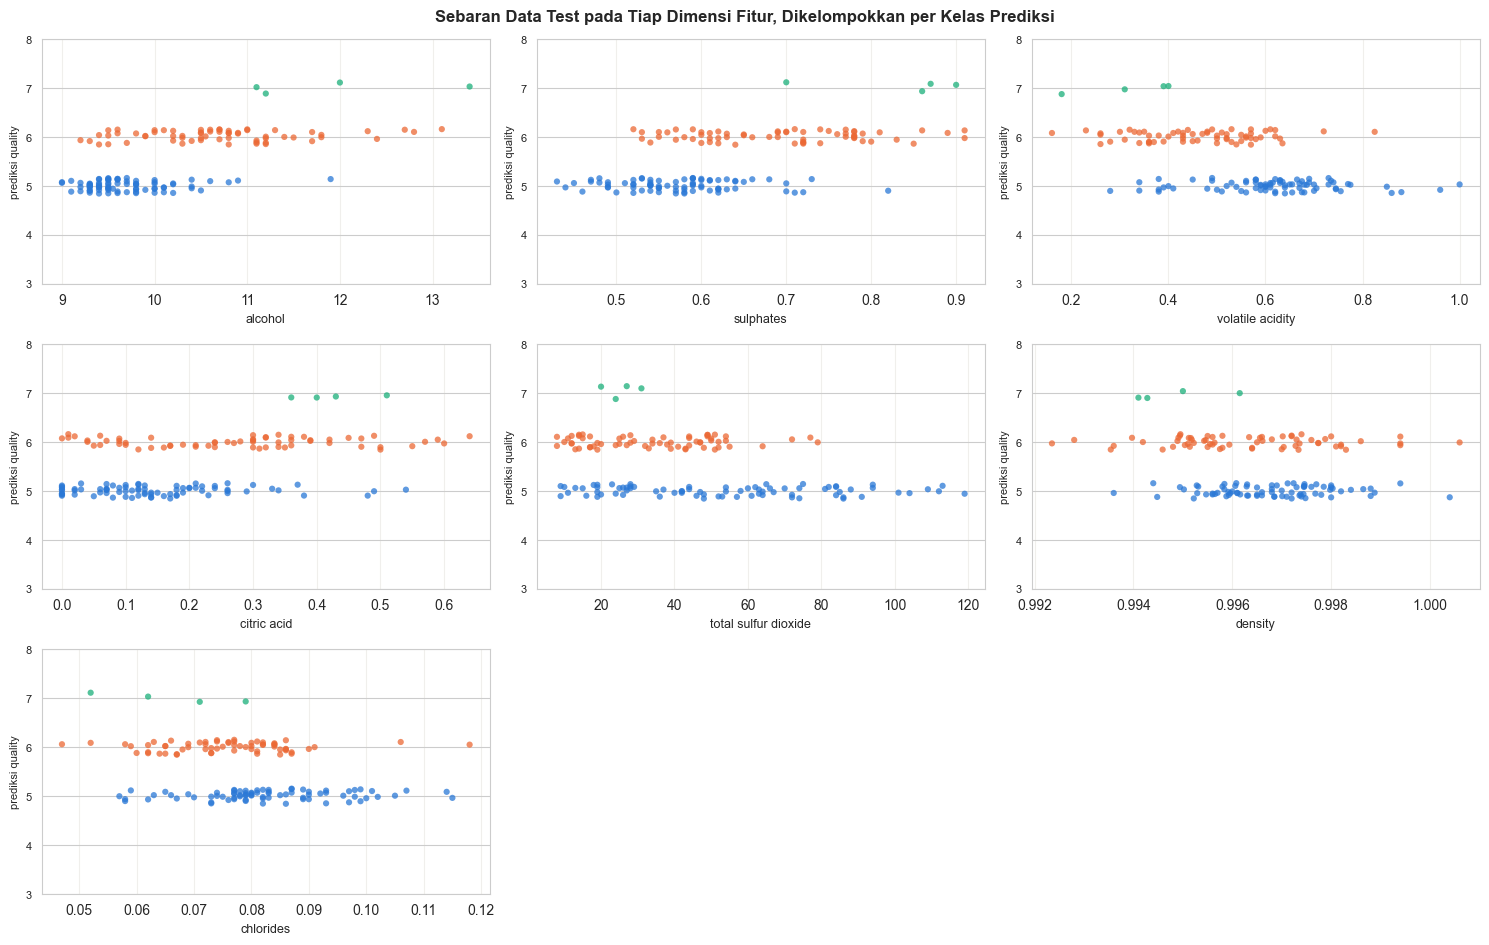

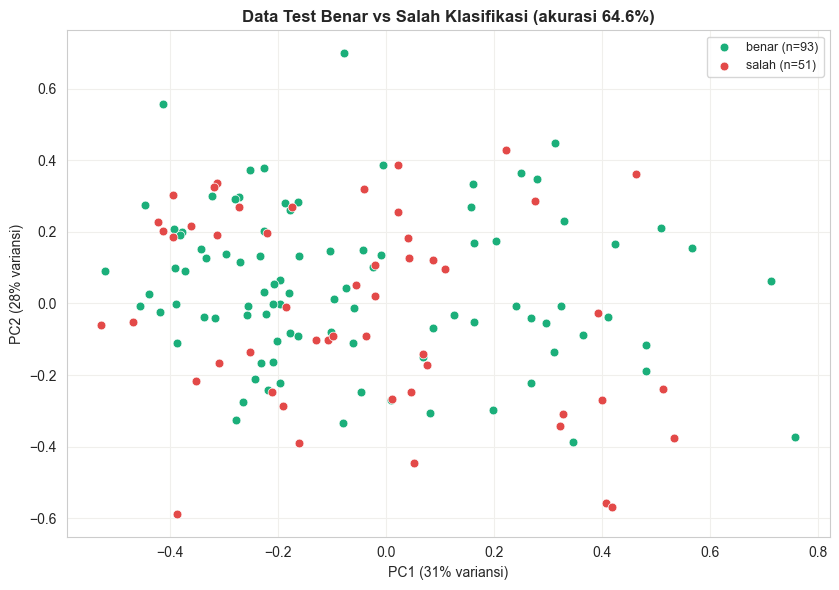

/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


                       skema  jml_kelas  tebak_mayoritas  akurasi_knn  selisih_thd_baseline  f1_macro
      6 kelas (quality asli)          6           0.4306       0.6458                0.2153    0.3361
3 kelas (cara notebook lain)          3           0.8611       0.8542               -0.0069    0.4438

Cara membacanya:
  - Kolom tebak_mayoritas = akurasi kalau kita SELALU menebak kelas terbanyak,
    tanpa belajar apa pun (dihitung manual, bukan model lain). Ini batas bawah yang wajib dilampaui.
  - Skema 3 kelas terlihat tinggi hanya karena kelas "normal" menguasai
    sebagian besar data, sehingga menebak asal saja sudah bernilai tinggi.
  - Yang menunjukkan model benar-benar belajar adalah selisih_thd_baseline.


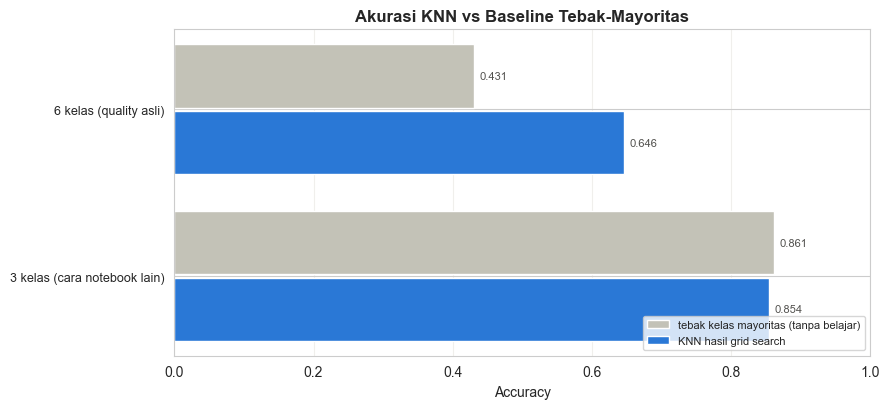

In [12]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

best_model = knn_models[(best_k, best_metric, best_weights)]
y_pred = best_model.predict(X_test_scaled)
labels = sorted(y.unique())

print(f'Model terbaik : k={best_k}, metric={best_metric}, weights={best_weights}')
print(f'Train accuracy: {accuracy_score(y_train, best_model.predict(X_train_scaled)):.4f}')
print(f'CV accuracy   : {grid.best_score_:.4f}')
print(f'Test accuracy : {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report (Precision, Recall, F1-Score per kelas):')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix (k={best_k}, {best_metric}, {best_weights})', fontsize=11, fontweight='bold')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else '#0b0b0b')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


# ============================================================
# SEMUA METRIK EVALUASI (accuracy, precision, recall, f1, dan lainnya)
# ============================================================
# Selain classification_report & confusion matrix di atas, berikut kumpulan metrik
# evaluasi klasifikasi standar (semua dihitung pada test set 20%, model KNN yang sama).
y_proba = best_model.predict_proba(X_test_scaled)
proba_labels = best_model.classes_  # urutan kolom y_proba mengikuti urutan ini

metrics_summary = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
    'Precision (macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
    'Precision (weighted)': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall (macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
    'Recall (weighted)': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score (macro)': f1_score(y_test, y_pred, average='macro', zero_division=0),
    'F1-Score (weighted)': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score (micro)': f1_score(y_test, y_pred, average='micro', zero_division=0),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred),
    'Matthews Corr. Coef. (MCC)': matthews_corrcoef(y_test, y_pred),
    'Jaccard Score (macro)': jaccard_score(y_test, y_pred, average='macro', zero_division=0),
    'Hamming Loss': hamming_loss(y_test, y_pred),
    'Zero-One Loss': zero_one_loss(y_test, y_pred),
}

# Metrik berbasis probabilitas (butuh predict_proba); dibungkus try/except karena bisa
# gagal jika ada kelas quality yang sampelnya terlalu sedikit di train atau test.
try:
    metrics_summary['Log Loss'] = log_loss(y_test, y_proba, labels=proba_labels)
except ValueError as e:
    metrics_summary['Log Loss'] = np.nan
    print(f'Log Loss dilewati: {e}')
try:
    # Batasi ke kelas yang benar-benar muncul di y_test: kelas yang tidak pernah
    # muncul di test set (misal quality=3 yang cuma 1-3 sampel) membuat AUC One-vs-Rest
    # tidak terdefinisi untuk kelas itu (y_true-nya cuma satu kelas / semua "rest").
    present_test_labels = [c for c in proba_labels if c in set(y_test.unique())]
    col_idx = [list(proba_labels).index(c) for c in present_test_labels]
    sub_proba = y_proba[:, col_idx]
    # Setelah kolom kelas yang tidak muncul di y_test dibuang, jumlah tiap baris
    # belum tentu 1.0 lagi (ada sisa probabilitas milik kelas yang dibuang) -> normalisasi ulang.
    row_sums = sub_proba.sum(axis=1, keepdims=True)
    sub_proba = np.divide(sub_proba, row_sums, out=np.zeros_like(sub_proba), where=row_sums > 0)
    metrics_summary['ROC-AUC (OvR, macro)'] = roc_auc_score(
        y_test, sub_proba, multi_class='ovr', average='macro', labels=present_test_labels)
except ValueError as e:
    metrics_summary['ROC-AUC (OvR, macro)'] = np.nan
    print(f'ROC-AUC dilewati: {e}')
try:
    metrics_summary['Top-2 Accuracy'] = top_k_accuracy_score(y_test, y_proba, k=2, labels=proba_labels)
except ValueError as e:
    metrics_summary['Top-2 Accuracy'] = np.nan
    print(f'Top-2 Accuracy dilewati: {e}')

metrics_df = pd.DataFrame({'Metric': list(metrics_summary.keys()), 'Value': list(metrics_summary.values())})
print('\n=== Ringkasan Semua Metrik Evaluasi (Test Set, model KNN terbaik) ===')
print(metrics_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6.5))
plot_df = metrics_df.dropna().sort_values('Value')
ax.barh(plot_df['Metric'], plot_df['Value'], color='#2a78d6')
ax.set_xlabel('Nilai Metrik')
ax.set_title('Ringkasan Semua Metrik Evaluasi pada Test Set', fontsize=12, fontweight='bold')
for i, v in enumerate(plot_df['Value']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
ax.grid(axis='x', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALISASI DATA TEST BERDASARKAN KELAS
# ============================================================

QCOLORS = {3: '#eda100', 4: '#e87ba4', 5: '#2a78d6', 6: '#eb6834', 7: '#1baf7a', 8: '#4a3aa7'}

# Fitur terpilih diproyeksikan ke 2 dimensi dengan PCA agar bisa digambar.
# PCA hanya untuk VISUALISASI; model tetap dilatih memakai seluruh fitur terpilih.
pca_viz = PCA(n_components=2, random_state=42).fit(X_train_scaled)
P_train = pca_viz.transform(X_train_scaled)
P_test = pca_viz.transform(X_test_scaled)
var1, var2 = pca_viz.explained_variance_ratio_[:2] * 100
correct = (y_pred == y_test.values)

# --- 1) Posisi tiap data test, dipisah per kelas asli ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, q in zip(axes.ravel(), labels):
    ax.scatter(P_test[:, 0], P_test[:, 1], s=18, color='#e1e0d9', zorder=1)
    m = (y_test.values == q)
    ax.scatter(P_test[m, 0], P_test[m, 1], s=34, color=QCOLORS[q],
               edgecolor='white', linewidth=.5, zorder=2)
    ax.set_title(f'quality = {q}  (n={m.sum()})', fontsize=10, fontweight='bold')
    ax.grid(color='#f0efec', lw=.8); ax.set_axisbelow(True)
for ax in axes[1]:
    ax.set_xlabel(f'PC1 ({var1:.0f}% variansi)')
for ax in axes[:, 0]:
    ax.set_ylabel(f'PC2 ({var2:.0f}% variansi)')
fig.suptitle('Posisi Data Test di Ruang Fitur, Dipisah per Kelas Asli', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 2) Wilayah keputusan KNN dan posisi data test ---
from matplotlib.colors import ListedColormap, BoundaryNorm

knn_2d = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, weights=best_weights).fit(P_train, y_train)
pad = 0.6
xx, yy = np.meshgrid(
    np.linspace(P_train[:, 0].min() - pad, P_train[:, 0].max() + pad, 300),
    np.linspace(P_train[:, 1].min() - pad, P_train[:, 1].max() + pad, 300))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
present = sorted(np.unique(Z))
bounds = [p - .5 for p in present] + [present[-1] + .5]
cmap = ListedColormap([QCOLORS[q] for q in present])

fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.contourf(xx, yy, Z, levels=bounds, cmap=cmap, norm=BoundaryNorm(bounds, cmap.N), alpha=.20)
for q in labels:
    m = (y_test.values == q) & correct
    if m.sum():
        ax.scatter(P_test[m, 0], P_test[m, 1], s=42, color=QCOLORS[q],
                   edgecolor='white', lw=.6, label=f'quality {q} (benar)', zorder=3)
ax.scatter(P_test[~correct, 0], P_test[~correct, 1], s=58, marker='x',
           color='#0b0b0b', lw=1.3, label='salah prediksi', zorder=4)
ax.set_xlabel(f'PC1 ({var1:.0f}% variansi)'); ax.set_ylabel(f'PC2 ({var2:.0f}% variansi)')
ax.set_title(f'Wilayah Keputusan KNN dan Posisi Data Test', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

predicted_classes = sorted(int(q) for q in np.unique(y_pred))
print(f'Kelas yang pernah diprediksi model : {predicted_classes}')
print(f'Kelas yang TIDAK pernah diprediksi : {[int(q) for q in labels if q not in predicted_classes]}'
      f' -> sampelnya terlalu sedikit untuk memenangkan voting tetangga.')

# --- 3) Sebaran data test pada tiap dimensi fitur ---
n_feat = len(selected_features)
ncol = 3
nrow = int(np.ceil(n_feat / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.2 * nrow))
rng = np.random.default_rng(0)
for ax, feat in zip(axes.ravel(), selected_features):
    vals = X_test[feat].values
    for i, q in enumerate(labels):
        m = (y_pred == q)
        if m.sum() == 0:
            continue
        ax.scatter(vals[m], np.full(m.sum(), i) + rng.uniform(-.16, .16, m.sum()),
                   s=20, color=QCOLORS[q], alpha=.75, edgecolor='none')
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('prediksi quality', fontsize=8)
    ax.grid(axis='x', color='#f0efec', lw=.8); ax.set_axisbelow(True)
for ax in axes.ravel()[n_feat:]:
    ax.axis('off')
fig.suptitle('Sebaran Data Test pada Tiap Dimensi Fitur, Dikelompokkan per Kelas Prediksi',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 4) Data test benar vs salah klasifikasi ---
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(P_test[correct, 0], P_test[correct, 1], s=40, color='#1baf7a',
           edgecolor='white', lw=.5, label=f'benar (n={correct.sum()})')
ax.scatter(P_test[~correct, 0], P_test[~correct, 1], s=40, color='#e34948',
           edgecolor='white', lw=.5, label=f'salah (n={(~correct).sum()})')
ax.set_xlabel(f'PC1 ({var1:.0f}% variansi)'); ax.set_ylabel(f'PC2 ({var2:.0f}% variansi)')
ax.set_title(f'Data Test Benar vs Salah Klasifikasi (akurasi {correct.mean():.1%})',
             fontsize=12, fontweight='bold')
ax.grid(color='#f0efec', lw=.8); ax.set_axisbelow(True)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# PERBANDINGAN TERHADAP BASELINE DAN TERHADAP SKEMA 3 KELAS
# (menjawab: kenapa notebook lain bisa ~0.85 sedangkan ini ~0.62)
# ============================================================

def bandingkan(y_target, nama):
    """Latih KNN grid search pada target tertentu, bandingkan dengan baseline
    'tebak kelas mayoritas' (dihitung manual, BUKAN model lain) yang tidak belajar apa pun.
    Sengaja tidak memakai model lain seperti DummyClassifier agar tetap hanya KNN
    yang dipakai sebagai model pembelajaran di seluruh notebook ini."""
    Xtr_, Xte_, ytr_, yte_ = train_test_split(
        data[selected_features], y_target, test_size=0.2, random_state=42, stratify=y_target)
    sc_ = StandardScaler()
    a_, b_ = sc_.fit_transform(Xtr_), sc_.transform(Xte_)

    majority_class = ytr_.mode().iloc[0]
    dummy_acc = (yte_ == majority_class).mean()
    gs_ = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1).fit(a_, ytr_)
    pred_ = gs_.best_estimator_.predict(b_)
    knn_acc = accuracy_score(yte_, pred_)

    return {
        'skema': nama,
        'jml_kelas': y_target.nunique(),
        'tebak_mayoritas': dummy_acc,
        'akurasi_knn': knn_acc,
        'selisih_thd_baseline': knn_acc - dummy_acc,
        'f1_macro': f1_score(yte_, pred_, average='macro'),
    }

quality_3kelas = pd.cut(data['quality'], bins=[0, 4, 6, 10], labels=['poor', 'normal', 'excellent'])

perbandingan = pd.DataFrame([
    bandingkan(data['quality'], '6 kelas (quality asli)'),
    bandingkan(quality_3kelas, '3 kelas (cara notebook lain)'),
])

print(perbandingan.round(4).to_string(index=False))
print()
print('Cara membacanya:')
print('  - Kolom tebak_mayoritas = akurasi kalau kita SELALU menebak kelas terbanyak,')
print('    tanpa belajar apa pun (dihitung manual, bukan model lain). Ini batas bawah yang wajib dilampaui.')
print('  - Skema 3 kelas terlihat tinggi hanya karena kelas "normal" menguasai')
print('    sebagian besar data, sehingga menebak asal saja sudah bernilai tinggi.')
print('  - Yang menunjukkan model benar-benar belajar adalah selisih_thd_baseline.')

fig, ax = plt.subplots(figsize=(9, 4.2))
ypos = np.arange(len(perbandingan))
ax.barh(ypos - .2, perbandingan['tebak_mayoritas'], height=.38,
        color='#c3c2b7', label='tebak kelas mayoritas (tanpa belajar)')
ax.barh(ypos + .2, perbandingan['akurasi_knn'], height=.38,
        color='#2a78d6', label='KNN hasil grid search')
ax.set_yticks(ypos)
ax.set_yticklabels(perbandingan['skema'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Accuracy')
ax.set_xlim(0, 1.0)
for i, r in enumerate(perbandingan.itertuples()):
    ax.text(r.tebak_mayoritas + .008, i - .2, f'{r.tebak_mayoritas:.3f}', va='center', fontsize=8, color='#52514e')
    ax.text(r.akurasi_knn + .008, i + .2, f'{r.akurasi_knn:.3f}', va='center', fontsize=8, color='#52514e')
ax.set_title('Akurasi KNN vs Baseline Tebak-Mayoritas', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='x', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

### Jawaban

Scaling terbukti meningkatkan performa KNN, dari akurasi 0,4861 tanpa scaling menjadi 0,5972 setelah scaling. Dari berbagai distance metric, Manhattan menjadi yang terbaik, terutama dengan k=61 dan weights=‘distance’, yang menghasilkan test accuracy 0,6458. Nilai k yang lebih besar juga cenderung lebih stabil karena kelas quality 5, 6, dan 7 memiliki karakteristik yang saling tumpang tindih. Namun, model masih kurang mampu memprediksi kelas minoritas seperti quality 3, 4, dan 8 karena jumlah datanya sedikit, terlihat dari Balanced Accuracy yang hanya 0,332.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Jawaban

Kesimpulan: Model terbaik adalah KNN dengan Manhattan, k=61, weights=distance, dan MinMaxScaler, dengan test accuracy 64,58% dan CV 59,97%. Manhattan dan nilai k besar memberikan performa terbaik, tetapi model masih kuat di kelas mayoritas dan kurang mampu menangani kelas minoritas akibat ketimpangan data.

Saran: Ketimpangan kelas dapat ditangani dengan oversampling/SMOTE, sementara quality sebaiknya diperlakukan sebagai label ordinal. Selain itu, ambang cleaning seperti IQR/Isolation Forest dapat dilonggarkan dan fitur turunan seperti rasio sulfur dioxide dapat ditambahkan untuk meningkatkan performa model.